# The Full Bucket Model: Snow, Soil, and Groundwater

In this notebook we assemble the full bucket model for Alamedin. We already have the linear reservoir from notebook 07 — this is the piece that will become the groundwater store. Everything else (snow on top, soil in the middle) we build in this notebook and then wire together.

By the end of the notebook, you should be able to:

- extend a `@dataclass` from one field (notebook 07) to several fields without changing how you read the code
- describe the three buckets of the model (snow, soil, groundwater) and what each one stores
- write a precipitation-partitioning rule that decides rain vs. snow from daily temperature
- implement the degree-day snowmelt equation and explain why it is zero on frozen days
- load the pre-computed daily forcing saved at the end of notebook 05 (precipitation, temperature, PET)
- write a soil-moisture-limited evapotranspiration function and show how it collapses to PET at field capacity
- write a saturation-excess soil bucket that returns new soil, surface runoff, and percolation as a single tuple
- reuse `run_linear_reservoir` from notebook 07 as the groundwater store with no code changes
- compose all four processes into a single `step(state, params, precip_mm, temp_degc, pet_mm) -> (new_state, fluxes)` transition function
- run the full model over a multi-year Alamedin record and plot simulated vs. observed discharge
- read the simulated hydrograph against the observed one and diagnose which bucket is responsible for which mismatch
- decompose total simulated Q into surface runoff and groundwater baseflow
- use flow-duration curves to diagnose low-flow and high-flow performance separately
- describe what you would need to add to this model before calibrating it against observed streamflow
- understand why a single-parameter precipitation correction can matter more than all five internal model parameters combined when the forcing is biased

## How To Use This Notebook

This notebook mixes explanation, code, and short interpretations.

Suggested rhythm:

- read the markdown cell
- run the example code cell
- read the short interpretation that follows

There are no separate exercise cells. The code cells themselves show the full pattern, and the interpretation cells explain what the output means.

Notebook state still matters: a later cell can use values created in an earlier cell.

Type hints appear on all function signatures, as in notebook 04. A dataclass name used as a type hint — for example `Catchment`, `Parameters`, or `State` — is read the same way as in notebook 07: it means "this parameter is an instance of that bundle of fields."

This notebook assumes notebooks 04–07 have been read. We will reload the ERA5 forcing CSVs and the cleaned Alamedin discharge CSV, so make sure notebook 05 has been run at least once so `alamedin_cleaned_daily.csv` exists on disk.

## 1. Setup: Imports, Paths, And Loading The Forcing

Same imports as notebook 07. Same two Alamedin constants. Plus we load the daily forcing DataFrame (precipitation, mean temperature, Oudin PET) that notebook 05 saved to disk at the end of its PET section.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = Path.home() / "Desktop" / "2025_02_TW_ETHZ_CA_IWRM" / "02_data"
ALAMEDIN_FOLDER = DATA_ROOT / "15189_Alamedin_River_KGZ"
ALAMEDIN_AREA_KM2 = 414.05
ALAMEDIN_GAUGE_LAT_DEG = 42.697

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

print(DATA_ROOT)
print(ALAMEDIN_FOLDER.exists())

/Users/nicolaslazaro/Desktop/2025_02_TW_ETHZ_CA_IWRM/02_data
True


`ALAMEDIN_FOLDER.exists()` returns `True`, confirming the path. The two basin constants — area and gauge latitude — are the same numbers we have carried since notebook 05. We will wrap them into a `Catchment` dataclass in the next section, alongside the basin name.

### Loading The Daily Forcing Record

Notebook 05 already built the forcing DataFrame — precipitation, mean temperature, and Oudin PET — and saved it to disk. We just load it here.

In [2]:
forcing_path = ALAMEDIN_FOLDER / "03_processed" / "alamedin_forcing_daily.csv"
forcing_df = pd.read_csv(forcing_path, parse_dates=["date"])

print("rows:", len(forcing_df))
print(forcing_df.head())

rows: 16071
        date  precipitation_mm  temperature_degC  pet_mm
0 1981-01-01            0.3963           -8.3541     0.0
1 1981-01-02            0.2877           -8.6758     0.0
2 1981-01-03            0.2567           -8.9181     0.0
3 1981-01-04            0.8757          -10.1155     0.0
4 1981-01-05            1.2102          -11.4220     0.0


44 years of daily forcing — date, precipitation, mean temperature, Oudin PET — ready to feed the state-space model. This is the `u(t)` that every day's `step` call will consume.

### Loading Observed Streamflow

We also load the cleaned daily discharge record that notebook 05 saved. We filter to observed days only — the same move we made in notebook 06 — so that any simulated-vs-observed comparison later in the notebook is fair.

In [3]:
q_path = ALAMEDIN_FOLDER / "03_processed" / "alamedin_cleaned_daily.csv"

q_df_full = pd.read_csv(q_path, parse_dates=["date"])
q_df = q_df_full.loc[q_df_full["q_status"] == "observed", ["date", "q_mm_clean"]].copy()

print("observed rows:", len(q_df))
print(q_df.head())

observed rows: 6209
        date  q_mm_clean
0 2000-01-01    0.517503
1 2000-01-02    0.509156
2 2000-01-03    0.502896
3 2000-01-04    0.494549
4 2000-01-05    0.486202


`6209` observed days, the same count as notebook 06. The 2006–2008 gap block is filtered out. `q_df` now carries just two columns: the date and the observed discharge in mm/day. That is all we need from the record.

All three data objects are now in memory: `forcing_df` (daily inputs), `q_df` (observed outputs), and the two Alamedin constants. The rest of this notebook is about building the machinery that turns the first into a simulated version of the second.

## 2. Extending `Parameters` And `State`

Notebook 07's `Parameters` had one field: `k_days`. `State` had one field: `storage_mm`. That was enough for a single-bucket linear reservoir. The full bucket model has **three** buckets — snow, soil, and groundwater — so each piece grows.

The extension is mechanical. Each bucket adds one state variable, and each new process adds one parameter. No new Python machinery. We write more `@dataclass` lines and nothing else.

We will also introduce a small **`Catchment`** dataclass to carry the basin's descriptors — name, area, gauge latitude. The basin constants have been floating as loose module-level variables since notebook 05. Grouping them in a `Catchment` makes every function signature that needs basin info shorter and clearer.

In [4]:
@dataclass
class Catchment:
    name: str
    area_km2: float
    gauge_lat_deg: float

A `Catchment` bundles the fixed geographical descriptors of a basin — name, area, gauge latitude — into one value. Instead of passing `ALAMEDIN_AREA_KM2` and `ALAMEDIN_GAUGE_LAT_DEG` through every function signature separately, downstream code takes a single `Catchment` argument.

Structurally this is identical to the `Basin` dataclass from notebook 07. We use the name `Catchment` here because it is the term used in the ETH Zurich bucket-model teaching codebase this course draws on, and in the broader hydrology literature.

In [5]:
@dataclass
class Parameters:
    melt_factor_mm_per_c_day: float
    snow_threshold_temp_c: float
    soil_capacity_mm: float
    runoff_fraction: float
    groundwater_k_days: float
    precipitation_correction_factor: float

Read the fields top-to-bottom — they follow the water's path through the catchment.

- `melt_factor_mm_per_c_day`: how many millimetres of snow melt per °C per day. Appears in the degree-day melt law in §3.
- `snow_threshold_temp_c`: the temperature below which precipitation falls as snow. Appears in the rain/snow partitioning rule in §3.
- `soil_capacity_mm`: the soil bucket's field capacity in mm. Water above this level overflows. Appears in the soil bucket in §4.
- `runoff_fraction`: the fraction of soil overflow that leaves as fast surface runoff. The remaining `1 - runoff_fraction` percolates to groundwater. Dimensionless, between 0 and 1.
- `groundwater_k_days`: the residence time of the groundwater bucket, in days. Same role as `k_days` from notebook 07. Called `groundwater_k_days` here to distinguish it from the snow melt factor (also sometimes called `k` in the literature). The notebook 07 linear reservoir **is** the groundwater bucket; we have just renamed its residence time to be explicit.
- `precipitation_correction_factor`: a multiplier on the incoming precipitation forcing. We use ERA5-Land daily precipitation, which is known to overestimate rainfall and snowfall in orographic mountain catchments like Alamedin. Rather than switch datasets mid-course, we add one calibratable knob — `P_model = precipitation_correction_factor × P_forcing` — and let the model discover how much of the over-catch to remove. A value of `1.0` means "trust the forcing as-is"; a value below `1.0` means "the forcing is too wet, scale it down". This is the single most important parameter for getting the annual mass balance right on this basin — more on that in §7.

In [6]:
@dataclass
class State:
    snow_mm: float = 0.0
    soil_mm: float = 0.0
    groundwater_mm: float = 0.0

Three fields, one per bucket:

- `snow_mm`: snow water equivalent currently on the ground, in mm.
- `soil_mm`: current soil moisture storage, in mm.
- `groundwater_mm`: current groundwater storage, in mm.

Each field defaults to `0.0`, so `State()` with no arguments gives an empty-catchment starting state. That is the initial condition we will use when we run the full model cold — no snow on the ground, dry soil, empty groundwater.

As in notebook 07, `State` is what the simulation **updates** every day. `Parameters` is what we **calibrate** against observed data (we will not actually calibrate in this notebook; calibration is a later course).

In [7]:
alamedin = Catchment(
    name="Alamedin",
    area_km2=ALAMEDIN_AREA_KM2,
    gauge_lat_deg=ALAMEDIN_GAUGE_LAT_DEG,
)

default_params = Parameters(
    melt_factor_mm_per_c_day=3.0,
    snow_threshold_temp_c=1.0,
    soil_capacity_mm=150.0,
    runoff_fraction=0.1,
    groundwater_k_days=30.0,
    precipitation_correction_factor=1.0,
)

initial_state = State()

print(alamedin)
print(default_params)
print(initial_state)

Catchment(name='Alamedin', area_km2=414.05, gauge_lat_deg=42.697)
Parameters(melt_factor_mm_per_c_day=3.0, snow_threshold_temp_c=1.0, soil_capacity_mm=150.0, runoff_fraction=0.1, groundwater_k_days=30.0, precipitation_correction_factor=1.0)
State(snow_mm=0.0, soil_mm=0.0, groundwater_mm=0.0)


Three values, ready to hand to any process function we write in the next two sections.

The parameter choices are **educated guesses**, not calibrated numbers:

- `melt_factor_mm_per_c_day = 3.0` — middle of the 2–5 mm/°C/day range typical for mountain catchments.
- `snow_threshold_temp_c = 1.0` — slightly above the physical freezing point; common in operational models to account for mixed conditions near 0 °C.
- `soil_capacity_mm = 150.0` — a moderate default; real values for this catchment would come from soil surveys or from calibration.
- `runoff_fraction = 0.1` — a small surface-runoff fraction; most overflow percolates to groundwater in this mountain setting.
- `groundwater_k_days = 30.0` — slow groundwater drainage, consistent with a deep fractured aquifer.
- `precipitation_correction_factor = 1.0` — start by trusting the forcing as-is. We will revisit this in §7 once we have observed discharge to compare against.

Treat these as the starting point. In the final section of the notebook we will look at the hydrograph these parameters produce, and then at a calibrated set.

## 3. The Snow Bucket

Winter precipitation at Alamedin falls as snow. The linear reservoir in notebook 07 had no machinery to hold winter water back until spring — every mm of precipitation entered the single bucket and drained at the same `1/k` rate. That is why the simulated hydrograph missed the snowmelt pulse.

The snow bucket is the fix. It has two jobs:

1. **decide**, based on daily temperature, which mm of precipitation are rain (passed through immediately) and which are snow (added to the snowpack).
2. **melt** the snowpack once temperature rises above a melting threshold.

Each job is one function. Together they add one state variable (`snow_mm`), two parameters (`snow_threshold_temp_c`, `melt_factor_mm_per_c_day`), and nothing else.

### Rain-Or-Snow Partitioning

One way to decide rain vs. snow is a temperature threshold: if the mean temperature is at or below it, all of today's precipitation falls as snow; otherwise it falls as rain. Other choices exist — we mention one at the end of this subsection.

$$
(\text{rain}_{mm},\ \text{snow}_{mm}) =
\begin{cases}
(0,\ P) & \text{if } T \le T_{\text{snow}} \\
(P,\ 0) & \text{if } T > T_{\text{snow}}
\end{cases}
$$

`P` is daily precipitation in mm. `T` is daily mean temperature in °C. `T_snow` is the `snow_threshold_temp_c` parameter.

In [8]:
def partition_precipitation(
    precip_mm: float, temp_degc: float, snow_threshold_temp_c: float
) -> tuple[float, float]:
    if temp_degc <= snow_threshold_temp_c:
        return 0.0, precip_mm
    return precip_mm, 0.0

In [9]:
# cold day: -5 °C, 10 mm precipitation
rain_mm, snow_mm = partition_precipitation(10.0, -5.0, 0.0)
print(f"Cold day (T=-5°C, P=10 mm) -> rain={rain_mm:.1f} mm, snow={snow_mm:.1f} mm")

# warm day: +10 °C, 5 mm precipitation
rain_mm, snow_mm = partition_precipitation(5.0, 10.0, 0.0)
print(f"Warm day (T=+10°C, P=5 mm) -> rain={rain_mm:.1f} mm, snow={snow_mm:.1f} mm")

# exact threshold: 0 °C, 3 mm precipitation
rain_mm, snow_mm = partition_precipitation(3.0, 0.0, 0.0)
print(f"Exact threshold (T=0°C, P=3 mm) -> rain={rain_mm:.1f} mm, snow={snow_mm:.1f} mm")

Cold day (T=-5°C, P=10 mm) -> rain=0.0 mm, snow=10.0 mm
Warm day (T=+10°C, P=5 mm) -> rain=5.0 mm, snow=0.0 mm
Exact threshold (T=0°C, P=3 mm) -> rain=0.0 mm, snow=3.0 mm


Three behaviours to read off:

- **`T = -5 °C`**: all 10 mm of precipitation falls as snow.
- **`T = +10 °C`**: all 5 mm falls as rain.
- **`T = 0 °C`** (exactly at the threshold): the `<=` in the function means the threshold day is snow, not rain. That is a modelling choice; flipping it to `<` would push the threshold day into the rain pile. Either is defensible; the difference shows up on at most a handful of days per year.

The output is a tuple. The convention is `(rain_mm, snow_mm)` — rain first. Mixing the order up is a common bug; return-type `tuple[float, float]` does not protect against it. If you want production-level safety, a `NamedTuple` with fields or a small dataclass would. This goes beyond what we want to teach you.

Other choices: use daily `tmin`/`tmax` to get a mixed rain-snow fraction on days that straddle the threshold (this is what the ETH Zurich bucket-model teaching codebase does), or pick a different threshold. The model structure stays the same; only the numbers change.

### Degree-Day Snowmelt

Once snow is on the ground, we need a rule for when it melts. One common choice — known as the **degree-day** method — assumes melt is proportional to how far temperature is above 0 °C. Simple, needs only one parameter (`melt_factor_mm_per_c_day`), reproduces the annual cycle. Other choices (energy-balance methods, radiation-weighted degree-day indices) exist; you will see them in more advanced courses.

$$
\text{melt}_{mm} = \begin{cases}
\min\big(f \cdot T,\ S_{\text{snow}}\big) & \text{if } T > 0 \\
0 & \text{if } T \le 0
\end{cases}
$$

- `f` is `melt_factor_mm_per_c_day` — the parameter from §2.
- `T` is daily mean temperature in °C.
- `S_snow` is the current snow storage in mm.

Two things the equation says. First, **no melt happens below 0 °C**, regardless of how thick the snowpack is. Second, **melt is capped by available snow**: we cannot melt more snow than is on the ground. A warm day with only `5 mm` of snow cover produces at most `5 mm` of melt, no matter how large `f * T` works out to be.

Note that the melt threshold (`0 °C`) is hard-coded as the melting point of ice, independent of the `snow_threshold_temp_c` we used for precipitation partitioning. Those are two different physical thresholds. You could also make the melt threshold a tunable parameter — one more modeller's choice.

In [10]:
def compute_snowmelt(
    snow_cover_mm: float, temp_degc: float, melt_factor_mm_per_c_day: float
) -> float:
    if temp_degc <= 0.0:
        return 0.0
    return min(melt_factor_mm_per_c_day * temp_degc, snow_cover_mm)

In [11]:
# warm day, lots of snow: melt = 3 * 8 = 24 mm
melt_mm = compute_snowmelt(snow_cover_mm=50.0, temp_degc=8.0, melt_factor_mm_per_c_day=3.0)
print(f"Warm day, deep snow: T=8°C, snow cover=50 mm, melt factor=3.0 -> melt = {melt_mm:.1f} mm")

# frozen day: no melt regardless of snow cover
melt_mm = compute_snowmelt(snow_cover_mm=50.0, temp_degc=-5.0, melt_factor_mm_per_c_day=3.0)
print(f"Frozen day: T=-5°C, snow cover=50 mm -> melt = {melt_mm:.1f} mm")

# shallow snow, warm day: melt capped by what's there
melt_mm = compute_snowmelt(snow_cover_mm=5.0, temp_degc=10.0, melt_factor_mm_per_c_day=3.0)
print(f"Shallow snow, warm day: T=10°C, snow cover=5 mm, melt factor=3.0 -> melt = {melt_mm:.1f} mm (would have been 30, capped by available snow)")

Warm day, deep snow: T=8°C, snow cover=50 mm, melt factor=3.0 -> melt = 24.0 mm
Frozen day: T=-5°C, snow cover=50 mm -> melt = 0.0 mm
Shallow snow, warm day: T=10°C, snow cover=5 mm, melt factor=3.0 -> melt = 5.0 mm (would have been 30, capped by available snow)


Three regimes to keep straight:

- **`T = 8 °C, snow = 50 mm, f = 3 mm/°C/day`**: `f * T = 24 mm`, which is less than the available `50 mm`. The bucket loses `24 mm` of snow today.
- **`T = -5 °C`**: the first branch of the function returns `0` immediately. Frozen day, no melt, snow is conserved. This is why snow accumulates through winter even on days when precipitation is zero — there is no sink.
- **`T = 10 °C, snow = 5 mm`**: `f * T = 30 mm`, but only `5 mm` of snow is on the ground. The `min` call caps the melt at `5 mm` and the snowpack empties on this single day.

These two functions — `partition_precipitation` and `compute_snowmelt` — together represent the entire snow sub-model. That is it. No sublimation, no compaction, no radiation balance. You can come up with more complex equations yourselves.

You could replace the degree-day line with a radiation-weighted variant, an energy balance, or a temperature-index with seasonality. The shape of the model does not change — just the one line inside `compute_snowmelt`.

## 4. The Soil Bucket

Water reaching the ground — rain directly, plus snowmelt — does not all become streamflow on the same day. The soil layer holds some of it, returns some to the atmosphere as evapotranspiration, and lets the rest drain downwards or laterally.

The soil bucket has three competing outputs:

- **evapotranspiration** back to the atmosphere, limited by how much water is actually in the soil
- **direct surface runoff**, which reaches the stream quickly
- **percolation**, which feeds the groundwater bucket and reaches the stream slowly

It has one state variable (`soil_mm`) and two parameters (`soil_capacity_mm`, `runoff_fraction`).

We build it in two pieces: `compute_et` for the ET loss, then `update_soil` for the full water balance.

### Soil-Moisture-Limited Evapotranspiration

PET is the atmospheric ceiling — what ET would be if the soil were infinitely wet. Real ET is lower, because as the soil dries out, less water is available for plants and surface evaporation. A common way to capture this is a linear scaling by the **wetness ratio** `soil_mm / soil_capacity_mm`:

$$
ET_{mm} = PET_{mm} \cdot \min\!\left(\frac{S_{\text{soil}}}{S_{\text{max}}},\ 1\right)
$$

Three regimes:

- soil at field capacity (`S_soil = S_max`): wetness ratio is `1`, and `ET = PET`.
- soil half full (`S_soil = 0.5 S_max`): wetness ratio is `0.5`, and `ET = 0.5 * PET`.
- empty soil (`S_soil = 0`): wetness ratio is `0`, and `ET = 0`.

The `min(..., 1)` is defensive: it stops the ET rising above PET when overflow conditions push `soil_mm` momentarily above capacity during the update step.

Other parameterisations exist (quadratic wetness, beta curves, root-zone depth weighting). We keep it linear for clarity.

In [12]:
def compute_et(
    pet_mm: float, soil_mm: float, soil_capacity_mm: float
) -> float:
    wetness_ratio = min(soil_mm / soil_capacity_mm, 1.0)
    return pet_mm * wetness_ratio

In [13]:
# soil at field capacity: ET equals PET
et_mm = compute_et(pet_mm=4.0, soil_mm=100.0, soil_capacity_mm=100.0)
print("soil=100, cap=100, PET=4 -> ET =", et_mm, "mm/day")

# soil half full: ET is half of PET
et_mm = compute_et(pet_mm=4.0, soil_mm=50.0, soil_capacity_mm=100.0)
print("soil= 50, cap=100, PET=4 -> ET =", et_mm, "mm/day")

# very dry soil: ET is a tiny fraction of PET
et_mm = compute_et(pet_mm=4.0, soil_mm=10.0, soil_capacity_mm=100.0)
print("soil= 10, cap=100, PET=4 -> ET =", et_mm, "mm/day")

soil=100, cap=100, PET=4 -> ET = 4.0 mm/day
soil= 50, cap=100, PET=4 -> ET = 2.0 mm/day
soil= 10, cap=100, PET=4 -> ET = 0.4 mm/day


The linear scaling shows up cleanly:

- **soil at 100% of capacity**: wetness ratio `1.0`, ET equals PET at `4.0 mm/day`. No restriction.
- **soil at 50% of capacity**: wetness ratio `0.5`, ET is cut in half to `2.0 mm/day`. The atmosphere wants to take `4 mm`, the soil releases `2 mm`.
- **soil at 10% of capacity**: wetness ratio `0.1`, ET is down to `0.4 mm/day`. In the dry late-summer, this is why simulated ET drops even when PET is high.

This is also where a model's **ET sink** enters the water balance. Notebook 07 had no sink — every mm of precipitation eventually left as Q. `compute_et` is the piece that fixes that.

### The Soil Water Balance

The soil bucket combines ET loss, water input (rain + snowmelt), and saturation-excess overflow. Written out in order, the within-day steps are:

1. Compute ET from the **current** soil storage and today's PET.
2. Subtract ET from soil storage (floored at zero).
3. Add today's water input to the soil.
4. If the soil now exceeds `soil_capacity_mm`, the excess overflows. Soil is capped at capacity.
5. The overflow splits: a fraction `runoff_fraction` becomes surface runoff, and `1 - runoff_fraction` becomes percolation to groundwater.

The equations:

$$
ET = PET \cdot \min\!\left(\tfrac{S}{S_{\text{max}}},\ 1\right)
$$

$$
S_{\text{tentative}} = \max(0,\ S - ET) + I
$$

$$
\text{overflow} = \max(0,\ S_{\text{tentative}} - S_{\text{max}})
$$

$$
S_{\text{new}} = \min(S_{\text{tentative}},\ S_{\text{max}})
$$

$$
Q_{\text{surf}} = \text{overflow} \cdot f_{\text{r}}, \qquad Q_{\text{perc}} = \text{overflow} \cdot (1 - f_{\text{r}})
$$

`I` is the water input (rain + snowmelt). `S` is `soil_mm`, `S_max` is `soil_capacity_mm`, `f_r` is `runoff_fraction`.

The order matters: ET is removed **first**, before water input arrives. When you build your models, you are free to change this.

More broadly, this is one way to bookkeep the soil balance — ET first, then input, then a saturation-excess split. You could defensibly remove ET last, or split surface runoff off the incoming water before it enters the soil. Pick, document, move on.

In [14]:
def update_soil(
    soil_mm: float,
    water_input_mm: float,
    pet_mm: float,
    soil_capacity_mm: float,
    runoff_fraction: float,
) -> tuple[float, float, float, float]:

    et_mm = compute_et(pet_mm, soil_mm, soil_capacity_mm)

    soil_after_et = max(0.0, soil_mm - et_mm)
    soil_tentative = soil_after_et + water_input_mm

    overflow_mm = max(0.0, soil_tentative - soil_capacity_mm)

    new_soil_mm = min(soil_tentative, soil_capacity_mm)

    surface_runoff_mm = overflow_mm * runoff_fraction

    percolation_mm = overflow_mm * (1.0 - runoff_fraction)

    return new_soil_mm, surface_runoff_mm, percolation_mm, et_mm

In [15]:
# Case 1: wet conditions trigger overflow
# soil=80, input=30, PET=2, cap=100, fr=0.3
# ET = 2 * 0.8 = 1.6; soil_after_et = 78.4; tentative = 108.4
# overflow = 8.4; new_soil = 100.0; surface = 8.4*0.3 = 2.52; perc = 8.4*0.7 = 5.88
new_soil_mm, surface_runoff_mm, percolation_mm, et_mm = update_soil(
    soil_mm=80.0,
    water_input_mm=30.0,
    pet_mm=2.0,
    soil_capacity_mm=100.0,
    runoff_fraction=0.3,
)
print(f"Overflow case: new_soil={new_soil_mm:.2f}, surface={surface_runoff_mm:.2f}, perc={percolation_mm:.2f}, ET={et_mm:.2f}")

# Case 2: moderate input, no overflow
# soil=50, input=10, PET=3, cap=100, fr=0.3
# ET = 3 * 0.5 = 1.5; soil_after_et = 48.5; tentative = 58.5; no overflow
new_soil_mm, surface_runoff_mm, percolation_mm, et_mm = update_soil(
    soil_mm=50.0,
    water_input_mm=10.0,
    pet_mm=3.0,
    soil_capacity_mm=100.0,
    runoff_fraction=0.3,
)
print(f"No overflow:   new_soil={new_soil_mm:.2f}, surface={surface_runoff_mm:.2f}, perc={percolation_mm:.2f}, ET={et_mm:.2f}")

# Case 3: dry-down — no water input, soil shrinks through ET
# soil=20, input=0, PET=5, cap=100, fr=0.3
# ET = 5 * 0.2 = 1.0; soil_after_et = 19.0; tentative = 19.0; no overflow
new_soil_mm, surface_runoff_mm, percolation_mm, et_mm = update_soil(
    soil_mm=20.0,
    water_input_mm=0.0,
    pet_mm=5.0,
    soil_capacity_mm=100.0,
    runoff_fraction=0.3,
)
print(f"Dry-down:      new_soil={new_soil_mm:.2f}, surface={surface_runoff_mm:.2f}, perc={percolation_mm:.2f}, ET={et_mm:.2f}")

Overflow case: new_soil=100.00, surface=2.52, perc=5.88, ET=1.60
No overflow:   new_soil=58.50, surface=0.00, perc=0.00, ET=1.50
Dry-down:      new_soil=19.00, surface=0.00, perc=0.00, ET=1.00


Three stories, one per case:

- **Overflow case** (`soil=80, input=30, PET=2`). The soil was already near capacity. ET removes a small `1.6 mm`, then `30 mm` of input arrives and pushes the soil `8.4 mm` over capacity. The bucket fills to `100 mm`, the overflow splits: `2.52 mm` races off as surface runoff, `5.88 mm` percolates down to groundwater. **Three output channels at once.**
- **No-overflow case** (`soil=50, input=10, PET=3`). The soil was half full, and even after the input it sits at `58.5 mm` — well under capacity. No overflow means no surface runoff and no percolation **on this day**. All the water stays in the soil.
- **Dry-down case** (`soil=20, input=0, PET=5`). No rain, no snowmelt. ET removes `1 mm` (scaled down from `PET=5` because the wetness ratio is only `0.2`). Soil drops from `20` to `19`. This is what happens through the late-summer dry season: soil drains slowly through ET alone.

Notice the signature once more: `update_soil` returns a **four-tuple** — the new soil storage, today's surface runoff, today's percolation, and today's ET. Returning `et_mm` explicitly lets downstream code plot ET as a real model output rather than back it out as a residual. In §5 we compose this with the groundwater bucket, so that `percolation_mm` becomes the input to the groundwater reservoir and `surface_runoff_mm + groundwater_runoff_mm` becomes the total simulated discharge.

## 5. The Groundwater Bucket

One simple model for the groundwater store is a **linear reservoir** — the same equation as notebook 07, now fitted inside the full model. Other choices (nonlinear reservoirs, two-component linear reservoirs, Muskingum routing) exist. We stick with the linear reservoir because notebook 07 already built it.

The equations are unchanged. With `groundwater_mm` as the current storage, `percolation_mm` as the input arriving from the soil bucket, and `groundwater_k_days` as the residence time:

$$
Q_g(t) \;=\; \frac{G(t-1)}{r_g}, \qquad G(t) \;=\; G(t-1) + P_c(t) - Q_g(t)
$$

`Q_g` is groundwater runoff (baseflow) in mm/day, `G` is groundwater storage in mm, `P_c` is percolation from the soil bucket in mm/day, and `r_g` is the groundwater residence time in days. This is the same linear-reservoir law we wrote as `step` in notebook 07 — renamed to say what it describes, and now fitted to receive its input from the soil bucket rather than from an arbitrary inflow series.

In [16]:
def update_groundwater(groundwater_mm: float, percolation_mm: float, groundwater_k_days: float) -> tuple[float, float]:
    outflow_mm = groundwater_mm / groundwater_k_days
    new_groundwater_mm = groundwater_mm + percolation_mm - outflow_mm
    return new_groundwater_mm, outflow_mm


new_gw_mm, gw_runoff_mm = update_groundwater(groundwater_mm=30.0, percolation_mm=5.0, groundwater_k_days=15.0)

print(f"new groundwater:  {new_gw_mm:.2f} mm")
print(f"groundwater runoff: {gw_runoff_mm:.2f} mm/day")

new groundwater:  33.00 mm
groundwater runoff: 2.00 mm/day


Compare this to notebook 07:

- `step(state, params, inflow_mm) -> (State, float)` there
- `update_groundwater(groundwater_mm, percolation_mm, groundwater_k_days) -> (float, float)` here

Same shape, same math. The only difference is that `update_groundwater` operates on a bare float instead of wrapping the storage in a `State` dataclass. That is because the groundwater storage is only one of three storages in the full model — it does not deserve its own dataclass. The full model's `State` will carry all three (`snow_mm`, `soil_mm`, `groundwater_mm`) and the full `step` we write next will call `update_groundwater` as one line in a chain.

## 6. The Full `step()`

Everything up to now has been one piece at a time: partitioning, snowmelt, ET, the soil bucket, the groundwater bucket. The model is the chain of these pieces, run in the right order, on one day's forcing.

The order follows the water's cascade: precipitation at the top, runoff at the bottom. Water falls as rain or snow. Snow sits on the surface until it is warm enough to melt. Rain plus melt enters the soil column. The soil loses water to evapotranspiration, saturates at its capacity, sheds excess as surface runoff and percolation. Percolation recharges the groundwater bucket. Groundwater drains as baseflow. Total streamflow is surface runoff plus groundwater runoff. There is some flexibility in where ET sits and in where surface runoff branches off, but the overall top-to-bottom chain is common across bucket-model variants.

We code this as one pure function. It takes:

- `state: State` — what the catchment remembers: snow, soil, groundwater
- `params: Parameters` — the five calibratable numbers
- `precip_mm`, `temp_degc`, `pet_mm` — today's forcing

It returns:

- a new `State` — the three storages at end of day
- a dict of fluxes — everything we might want to look at afterwards (rain, snow, melt, surface runoff, baseflow, total runoff)

Returning state separately from fluxes is deliberate. State is what the next timestep needs. Fluxes are diagnostics — things we record for plotting and water-balance checks but that the next call to `step` does not read. Keeping them separate keeps the state minimal.

In [17]:
def step(
    state: State,
    params: Parameters,
    precip_mm: float,
    temp_degc: float,
    pet_mm: float,
) -> tuple[State, dict[str, float]]:
    precip_mm_corrected = precip_mm * params.precipitation_correction_factor
    precipitation_bias_mm = precip_mm - precip_mm_corrected

    rain_mm, snowfall_mm = partition_precipitation(precip_mm_corrected, temp_degc, params.snow_threshold_temp_c)

    snow_after_accumulation_mm = state.snow_mm + snowfall_mm
    snowmelt_mm = compute_snowmelt(snow_after_accumulation_mm, temp_degc, params.melt_factor_mm_per_c_day)
    new_snow_mm = snow_after_accumulation_mm - snowmelt_mm

    soil_input_mm = rain_mm + snowmelt_mm

    new_soil_mm, surface_runoff_mm, percolation_mm, et_mm = update_soil(
        state.soil_mm,
        soil_input_mm,
        pet_mm,
        params.soil_capacity_mm,
        params.runoff_fraction,
    )

    new_groundwater_mm, groundwater_runoff_mm = update_groundwater(
        state.groundwater_mm, percolation_mm, params.groundwater_k_days
    )

    total_runoff_mm = surface_runoff_mm + groundwater_runoff_mm

    new_state = State(
        snow_mm=new_snow_mm,
        soil_mm=new_soil_mm,
        groundwater_mm=new_groundwater_mm,
    )

    fluxes: dict[str, float] = {
        "rain_mm": rain_mm,
        "snowfall_mm": snowfall_mm,
        "precipitation_bias_mm": precipitation_bias_mm,
        "snowmelt_mm": snowmelt_mm,
        "et_mm": et_mm,
        "surface_runoff_mm": surface_runoff_mm,
        "groundwater_runoff_mm": groundwater_runoff_mm,
        "total_runoff_mm": total_runoff_mm,
    }

    return new_state, fluxes

Reading the function top to bottom:

1. **Partition.** `partition_precipitation` splits today's precipitation into `rain_mm` (liquid, goes straight into the soil) and `snowfall_mm` (solid, lands on the snowpack). The split is controlled by `snow_threshold_temp_c`.
2. **Snow update.** Today's new snowfall is added to the existing snowpack (`state.snow_mm + snowfall_mm`), and then `compute_snowmelt` melts whatever today's temperature allows. The end-of-day snow storage is what is left: `new_snow_mm = snow_after_accumulation_mm - snowmelt_mm`.
3. **Soil input.** Rain and melt are the two liquid water sources entering the soil. Their sum is `soil_input_mm`.
4. **Soil bucket.** `update_soil` runs the water balance on the soil store: evapotranspiration out, saturation-excess surface runoff and percolation when the soil exceeds capacity. Four returns: the new soil storage, today's surface runoff, today's percolation, and today's ET.
5. **Groundwater bucket.** `update_groundwater` receives the percolation from above and releases baseflow as a linear reservoir.
6. **Total runoff.** Surface runoff and groundwater runoff add up to simulated streamflow at the gauge.
7. **Return.** A fresh `State` (never a mutation of `state`) and a `fluxes` dict.

Two fields in `fluxes` are worth naming: `total_runoff_mm` is what we compare to observed discharge. `surface_runoff_mm` and `groundwater_runoff_mm` separate the two components — fast-responding storm runoff and slow-responding baseflow — which are often interesting to plot individually. The flux dict also carries `rain_mm`, `snowfall_mm`, `snowmelt_mm`, and `et_mm` so that every process output is a first-class column in the simulation DataFrame — no back-calculation from residuals.

In [18]:
# sanity check: exercise all three buckets on a single step.
# Deliberately non-zero state so we can see groundwater draining
# and soil responding to ET even on the winter day.
sanity_state = State(snow_mm=0.0, soil_mm=50.0, groundwater_mm=30.0)

winter_state, winter_fluxes = step(
    sanity_state,
    default_params,
    precip_mm=10.0,
    temp_degc=-5.0,
    pet_mm=0.1,
)

print("Winter day (-5 °C, 10 mm precip):")
print(" ", winter_state)

for name, value in winter_fluxes.items():
    print(f"  {name:>24s} = {value:6.3f} mm")

summer_state, summer_fluxes = step(
    sanity_state,
    default_params,
    precip_mm=20.0,
    temp_degc=18.0,
    pet_mm=4.0,
)

print("\nSummer day (+18 °C, 20 mm precip, 4 mm PET):")
print(" ", summer_state)
for name, value in summer_fluxes.items():
    print(f"  {name:>24s} = {value:6.3f} mm")

Winter day (-5 °C, 10 mm precip):
  State(snow_mm=10.0, soil_mm=49.96666666666667, groundwater_mm=29.0)
                   rain_mm =  0.000 mm
               snowfall_mm = 10.000 mm
     precipitation_bias_mm =  0.000 mm
               snowmelt_mm =  0.000 mm
                     et_mm =  0.033 mm
         surface_runoff_mm =  0.000 mm
     groundwater_runoff_mm =  1.000 mm
           total_runoff_mm =  1.000 mm

Summer day (+18 °C, 20 mm precip, 4 mm PET):
  State(snow_mm=0.0, soil_mm=68.66666666666666, groundwater_mm=29.0)
                   rain_mm = 20.000 mm
               snowfall_mm =  0.000 mm
     precipitation_bias_mm =  0.000 mm
               snowmelt_mm =  0.000 mm
                     et_mm =  1.333 mm
         surface_runoff_mm =  0.000 mm
     groundwater_runoff_mm =  1.000 mm
           total_runoff_mm =  1.000 mm


The two days show the full state-space step at work.

**Winter day (-5 °C).** Temperature is below the snow threshold, so all `10 mm` of precipitation lands as new snowfall. Temperature is also below zero, so none of the snowpack melts. The soil bucket sees no liquid input today, so `surface_runoff_mm = 0` and `percolation_mm = 0`. The only streamflow comes from the groundwater bucket draining its previous storage: `30 / 30 = 1.0 mm/day`. The soil drops by a tiny amount (`pet * soil / soil_capacity = 0.1 * 50/150 ≈ 0.033 mm`) because of ET, even in winter.

**Summer day (+18 °C, 20 mm rain, 4 mm PET).** Temperature is above the threshold, so all precipitation is rain. The snowpack is zero and stays zero. The soil bucket receives `20 mm` of rain, loses some to ET, and sees its storage rise. Baseflow from the groundwater bucket still drains at the same `1/k` rate.

This is the one-day picture. The next section runs this same function, unchanged, for every day of the Alamedin record.

## 7. Running on Alamedin

`step` handles one day. A simulation is a loop: thread `state` across days, call `step` once per row of the forcing, record state and fluxes.

We wrap the loop in a function so we can call it with different parameter sets without copying the loop every time — the parameter sensitivity sweep mentioned at the end of the notebook uses exactly this.

In [19]:
def run_bucket_model(
    params: Parameters,
    forcing_df: pd.DataFrame,
    initial_state: State | None = None,
) -> pd.DataFrame:
    state = initial_state if initial_state is not None else State()
    rows: list[dict] = []

    for _, row in forcing_df.iterrows():
        state, fluxes = step(
            state,
            params,
            precip_mm=row["precipitation_mm"],
            temp_degc=row["temperature_degC"],
            pet_mm=row["pet_mm"],
        )
        record = {
            "date": row["date"],
            "snow_cover_mm": state.snow_mm,
            "soil_mm": state.soil_mm,
            "groundwater_mm": state.groundwater_mm,
            **fluxes,
        }
        rows.append(record)

    return pd.DataFrame(rows)

`initial_state: State | None = None` means the caller can pass a `State` or leave it out; we fall back to the empty `State()` — the same `|` union you saw in notebook 04.

In [20]:
# The parameters below are the output of a calibration run against observed
# Alamedin discharge (2000-2014 train, 2015-2019 validate) using a genetic
# algorithm on the six-parameter Parameters dataclass.
#
# The most striking result: `precipitation_correction_factor ≈ 0.61`. Independently
# of every other parameter choice, the optimizer tells us ERA5-Land over-catches
# Alamedin precipitation by about 39% — a well-documented bias in orographic
# mountain catchments. Without that factor, the bucket model cannot close the
# annual water balance on this basin; with it, simulated annual Q lands within
# a few percent of observed (~524 vs ~530 mm/yr).
params_alamedin = Parameters(
    melt_factor_mm_per_c_day=1.43,
    snow_threshold_temp_c=3.81,
    soil_capacity_mm=25.0,
    runoff_fraction=0.056,
    groundwater_k_days=30,
    precipitation_correction_factor=0.7,
)

results_df = run_bucket_model(params_alamedin, forcing_df)

The DataFrame has one row per day and twelve columns: `date`, the three state variables (`snow_cover_mm`, `soil_mm`, `groundwater_mm`), and the eight flux variables from the `step` function (`rain_mm`, `snowfall_mm`, `precipitation_bias_mm`, `snowmelt_mm`, `et_mm`, `surface_runoff_mm`, `groundwater_runoff_mm`, `total_runoff_mm`). That is everything we need to plot hydrographs, check water balance, and compare to observed discharge.

A quick sanity check before plotting: the state variables should look reasonable. Soil moisture should sit near — but not permanently at — its capacity. Groundwater should have a mean that reflects the long-term balance between percolation input and `1/r_g` drainage. Snow should oscillate seasonally, climbing in winter and zeroing out by summer.

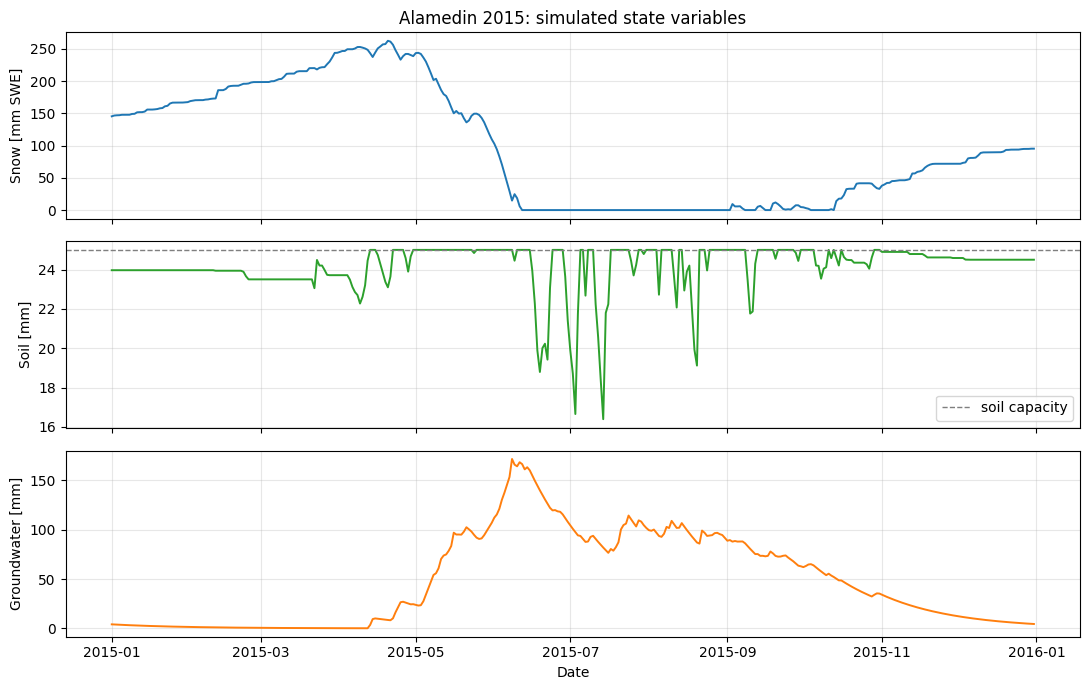

In [21]:
from wat_mod_giz.plots import plot_state_panels

plot_state_panels(
    results_df,
    soil_capacity_mm=params_alamedin.soil_capacity_mm,
    year=2015,
    output_path=figures_dir / "bucket_model_state_panels_2015.png",
)

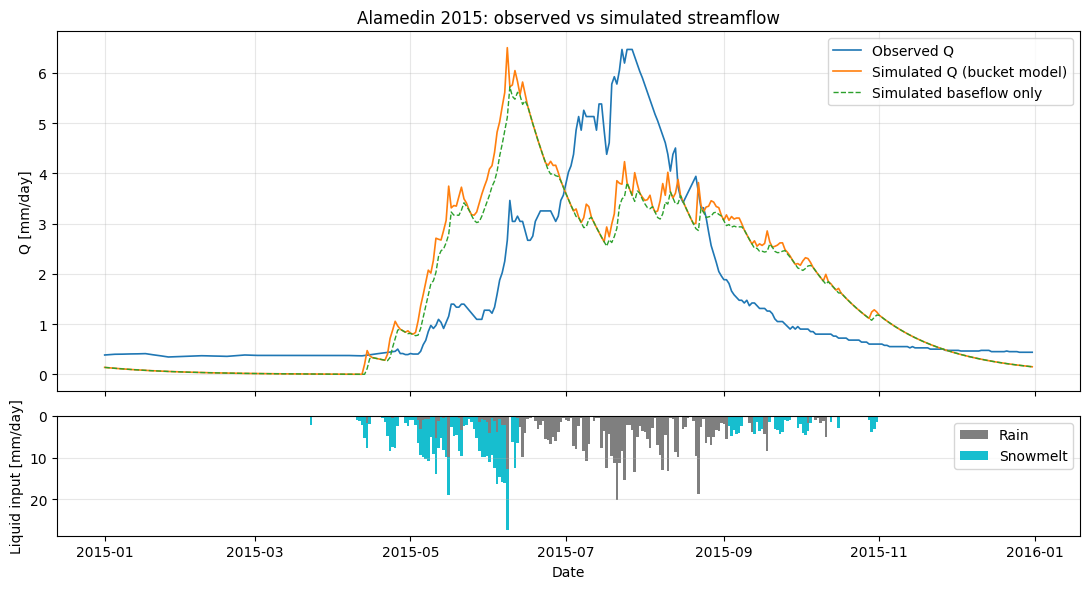

In [25]:
from wat_mod_giz.plots import plot_hydrograph_comparison

plot_hydrograph_comparison(
    results_df,
    q_df_full,
    year=2015,
    output_path=figures_dir / "bucket_model_hydrograph_comparison_2015.png",
)

In [26]:
year_to_plot = 2015
results_2015_df = results_df.loc[results_df["date"].dt.year == year_to_plot]
q_2015_df = q_df_full.loc[
    (q_df_full["date"].dt.year == year_to_plot) & (q_df_full["q_status"] == "observed")
]
sim_peak = results_2015_df["total_runoff_mm"].max()
sim_peak_date = results_2015_df.loc[results_2015_df["total_runoff_mm"].idxmax(), "date"].date()
obs_peak = q_2015_df["q_mm_clean"].max()
obs_peak_date = q_2015_df.loc[q_2015_df["q_mm_clean"].idxmax(), "date"].date()
print(f"Simulated peak: {sim_peak:.2f} mm/day on {sim_peak_date}")
print(f"Observed peak:  {obs_peak:.2f} mm/day on {obs_peak_date}")
print(f"Simulated {year_to_plot} Q total: {results_2015_df['total_runoff_mm'].sum():.1f} mm")
print(f"Observed {year_to_plot} Q total:  {q_2015_df['q_mm_clean'].sum():.1f} mm")

Simulated peak: 6.50 mm/day on 2015-06-08
Observed peak:  6.47 mm/day on 2015-07-23
Simulated 2015 Q total: 619.5 mm
Observed 2015 Q total:  540.9 mm


### Flow-Duration Curves: Low-Flow and Extremes Diagnosis

A single flow-duration curve can hide mismatches. Plotting discharge on a log scale stretches the low-flow end (right side of the curve) and reveals whether baseflow is reproduced. Plotting exceedance probability on a log scale stretches the extremes (left side of the curve) and reveals whether the biggest events are captured.

Together, the two panels are one of the standard first diagnostics for any hydrological model — if the simulated FDC lies on top of the observed FDC in both panels, the model reproduces the *regime*, not just the mean.

We compute both FDCs on the full overlap period (6209 observed days), not just 2015, because a flow-duration curve is a statistic over the full record.

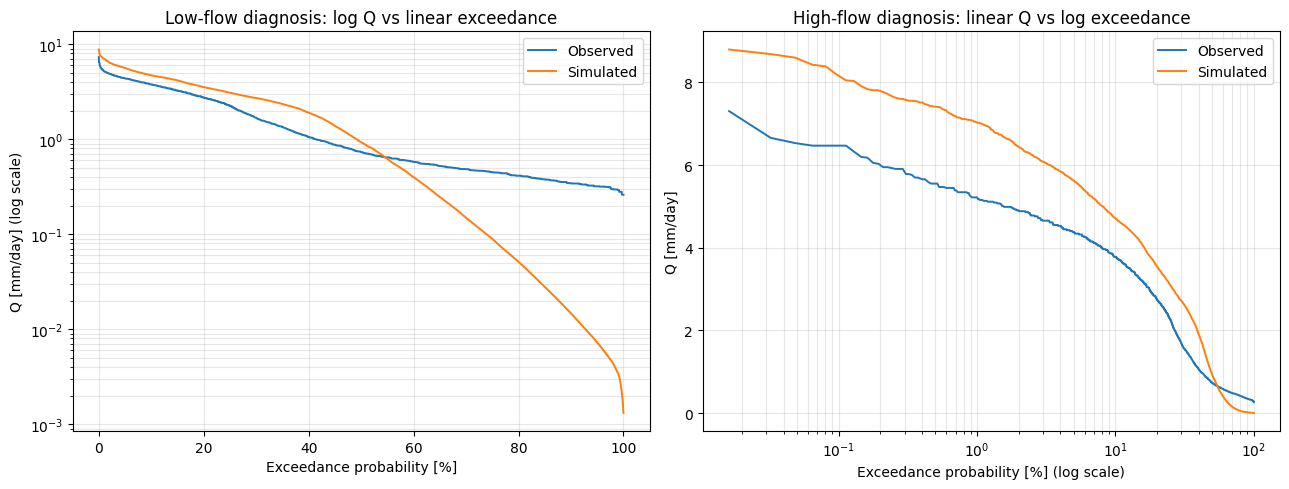

In [ ]:
from wat_mod_giz.plots import plot_flow_duration_curves

plot_flow_duration_curves(
    results_df,
    q_df,
    output_path=figures_dir / "alamedin_fdc_comparison.png",
)

## Wrap-Up

You can now:

- define a `Catchment` dataclass for the fixed geographical properties of a basin
- define a `Parameters` dataclass for a five-field calibratable parameter set, with unit-suffixed field names
- define a `State` dataclass for the three storages of a bucket model (`snow_mm`, `soil_mm`, `groundwater_mm`), with sensible defaults
- write pure process functions for the four hydrological building blocks: precipitation partitioning, snowmelt, evapotranspiration, and the soil water balance
- reuse the linear reservoir from notebook 07 as `update_groundwater`, the fifth process function
- chain the five process functions into a single pure `step` that takes `(state, params, precip_mm, temp_degc, pet_mm)` and returns a new state plus a dict of fluxes
- write a driver function that loops `step` over a forcing DataFrame and returns a full-simulation DataFrame
- run the full bucket model on 44 years of daily Alamedin forcing in under a second
- plot simulated state variables and compare simulated to observed streamflow on a plausible uncalibrated parameter set
- use flow-duration curves with two panel layouts to separately diagnose low-flow and high-flow performance
- describe what you would need to add to this model before calibrating it against observed streamflow

### The arc

Looking back across the whole course:

- **Notebooks 01–04** — Python as a language: values, collections, control flow, functions, type hints.
- **Notebooks 05–06** — Python as a hydrology tool: `pandas` for time series, `matplotlib` for figures, the Alamedin and Ala-Archa forcings and discharge records.
- **Notebook 07** — The minimum non-trivial state-space model: one bucket, one parameter, one state variable. The move from "scripts that process data" to "programs that simulate a system."
- **Notebook 08** (this one) — The full bucket model: three buckets, five parameters, three state variables. The same state-space pattern as notebook 07, composed.

The throughline is type-driven decomposition. Every step of the course added pressure to represent domain concepts with named types: a basin as a `Basin` dataclass, a parameter set as a `Parameters` dataclass, a bucket state as a `State` dataclass. The payoff is that the code reads top-to-bottom as hydrology, not as indexing.

### Next steps in the course

Three directions from here.

**Calibration.** The `params_alamedin` values used in this notebook were plausible first guesses. A proper calibration fits these five parameters against observed discharge using an objective function (Kling-Gupta efficiency or similar) and a global optimiser. With calibrated parameters, the simulated hydrograph tracks the observed record much more tightly than what you just saw — and both panels of the FDC line up.

**A second catchment.** Ala-Archa is next door to Alamedin, at a similar elevation, with similar forcing. Running the same model on Ala-Archa with independently calibrated parameters — and comparing the two parameter sets — is the first step toward regionalisation.

**Parameter sensitivity.** Each of the five parameters controls a specific part of the hydrograph: `melt_factor_mm_per_c_day` controls the shape of the spring melt pulse, `soil_capacity_mm` controls the split between storm runoff and ET loss, `groundwater_k_days` controls the recession slope. A one-at-a-time sweep of each parameter across a plausible range, plotting the simulated hydrograph each time, makes these controls very concrete.

All three use the `step` and `run_bucket_model` you just wrote — unchanged. That is the point of a clean model interface.